In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score
from tscglue.models import LokyStackerV10FM
from tscglue import data_loader
import polars as pl
from sklearn.metrics import log_loss

In [3]:
dataset = "Worms"
# dataset = 'Car'
# dataset = 'HandOutlines'
#dataset = 'Trace'
#dataset = 'SwedishLeaf'
#dataset = 'Meat'
# dataset='ACSF1'
# dataset='MedicalImages'
X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, 19)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(181, 1, 900) (181,) (77, 1, 900) (77,)


In [4]:
seed = 2683

In [5]:
from tscglue.models import LokyStackerV10RSTSFRandom


m = LokyStackerV10RSTSFRandom(random_state=seed, n_jobs=16, keep_features=True, verbose=10, n_repetitions=1)

In [6]:
m.fit(X_train, y_train)

[0.00s] Starting fit, run_dir=tscglue_runs/935aa903253e46b7, n_jobs=16
[0.00s] Saved X and y to disk in 0.00s (dtype=float64)


[3.18s] Fit+transformed multirocket_s_1675711793 features (181, 49728) (68.67 MB) dtype=float64 in 3.0024s
[subprocess] fit_transform hydra_s_2109509380: 2.8977s
[12.27s] Fit+transformed hydra_s_2109509380 features (181, 7168) (9.90 MB) dtype=float64 in 9.0851s
[subprocess] fit_transform quant: 2.8436s
[20.59s] Fit+transformed quant features (181, 7987) (11.03 MB) dtype=float64 in 8.3240s
[32.21s] Fit+transformed rdst_s_1973074453 features (181, 30000) (41.43 MB) dtype=float64 in 11.6150s
[RSTSFRandomTransformer] series transforms: 0.28s
[RSTSFRandomTransformer] fit RI  rep=raw: 0.41s
[RSTSFRandomTransformer] fit RI  rep=diff: 0.41s
[RSTSFRandomTransformer] fit RI  rep=periodogram: 0.43s
[RSTSFRandomTransformer] fit RI  rep=ar: 0.40s
[RSTSFRandomTransformer] transform series reps: 0.17s
[RSTSFRandomTransformer] transform RI  rep=raw: 2.16s
[RSTSFRandomTransformer] transform RI  rep=diff: 2.51s
[RSTSFRandomTransformer] transform RI  rep=periodogram: 1.61s
[RSTSFRandomTransformer] transf

,random_state,2683
,k_folds,10
,n_jobs,16
,keep_features,True
,verbose,10
,model_names,None
,n_repetitions,1
,feature_dtype,dtype('float64')


In [7]:
m.classes_

array(['1', '2', '3', '4', '5'], dtype='<U1')

In [8]:
y_pred = m.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on {dataset}: {acc}")

[0.00s] Starting prediction


[1.15s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 1.0446s
[subprocess] transform hydra_s_2109509380: 1.3617s
[9.25s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 8.0984s
[subprocess] transform quant: 1.1520s
[16.53s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 7.2843s
[20.04s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 3.5146s
[RSTSFRandomTransformer] transform series reps: 0.08s
[RSTSFRandomTransformer] transform RI  rep=raw: 0.93s
[RSTSFRandomTransformer] transform RI  rep=diff: 1.02s
[RSTSFRandomTransformer] transform RI  rep=periodogram: 0.74s
[RSTSFRandomTransformer] transform RI  rep=ar: 0.06s
[22.90s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 2.8557s
[subprocess] transform mantis: 4.5667s
[38.83s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 15.9341s
[subprocess] transform chronos2: 14.3060s
[64.73s] Co

In [9]:
proba = m.predict_proba(X_test)
classes = list(m.classes_)

print(f"Log-loss: {log_loss(y_test, proba, labels=classes):.4f}")
# print(f"AUC (OvR): {roc_auc_score(y_test, proba, multi_class='ovr', labels=classes):.4f}")

[0.00s] Starting prediction
[1.07s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 0.9996s
[subprocess] transform hydra_s_2109509380: 1.3460s
[8.57s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 7.5003s
[subprocess] transform quant: 0.9708s
[15.81s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 7.2372s
[19.40s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 3.5900s
[RSTSFRandomTransformer] transform series reps: 0.09s
[RSTSFRandomTransformer] transform RI  rep=raw: 0.81s
[RSTSFRandomTransformer] transform RI  rep=diff: 1.09s
[RSTSFRandomTransformer] transform RI  rep=periodogram: 0.77s
[RSTSFRandomTransformer] transform RI  rep=ar: 0.08s
[22.28s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 2.8771s
[subprocess] transform mantis: 4.8308s
[38.74s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 16.4614s
[subprocess] transform ch

In [10]:
pl.DataFrame(m.neki)

index,model,level,class,probability
i64,str,i64,str,f64
0,"""multirockethydra-bestk-p-ridge…",0,"""1""",0.487761
0,"""multirockethydra-bestk-p-ridge…",0,"""2""",0.21295
0,"""multirockethydra-bestk-p-ridge…",0,"""3""",0.122361
0,"""multirockethydra-bestk-p-ridge…",0,"""4""",0.083505
0,"""multirockethydra-bestk-p-ridge…",0,"""5""",0.093423
…,…,…,…,…
170,"""probability-ridgecv""",1,"""1""",1.0
170,"""probability-ridgecv""",1,"""2""",0.0
170,"""probability-ridgecv""",1,"""3""",0.0


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TS

[0.00s] Starting prediction


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[0.83s] Computed multirocket_s_1675711793 features (77, 49728) (29.21 MB) dtype=float64 in 0.7877s
[subprocess] transform hydra_s_2109509380: 0.9150s
[7.56s] Computed hydra_s_2109509380 features (77, 7168) (4.21 MB) dtype=float64 in 6.7299s
[subprocess] transform quant: 0.9766s
[12.10s] Computed quant features (77, 7987) (4.69 MB) dtype=float64 in 4.5399s
[15.36s] Computed rdst_s_1973074453 features (77, 30000) (17.62 MB) dtype=float64 in 3.2643s
[RSTSFRandomTransformer] transform series reps: 0.08s
[RSTSFRandomTransformer] transform RI  rep=raw: 0.67s
[RSTSFRandomTransformer] transform RI  rep=diff: 1.08s
[RSTSFRandomTransformer] transform RI  rep=periodogram: 0.71s
[RSTSFRandomTransformer] transform RI  rep=ar: 0.07s
[17.99s] Computed rstsf-random_s_447740098 features (77, 13622) (8.00 MB) dtype=float64 in 2.6303s
[subprocess] transform mantis: 2.6659s
[29.79s] Computed mantis features (77, 512) (0.30 MB) dtype=float64 in 11.7990s
[subprocess] transform chronos2: 13.9415s
[55.34s] Co

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RidgeCV   OOF mean=0.7595 std=0.0098  test=0.8052
RF        OOF mean=0.7643 std=0.0110  test=0.7922
HGBT      OOF mean=0.7501 std=0.0171  test=0.7662
MLP       OOF mean=0.7653 std=0.0114  test=0.7792


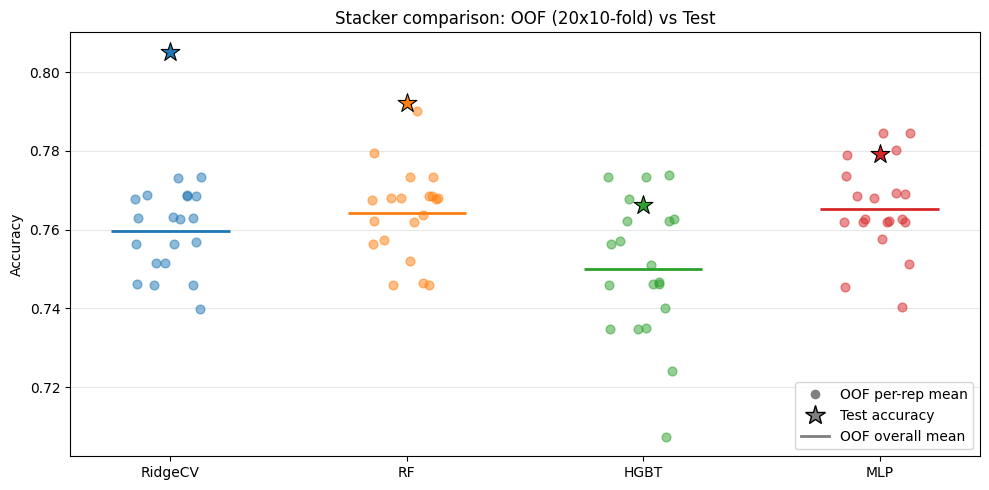

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Build probability matrix from level-0 neki predictions
df = pl.DataFrame(m.neki).filter(pl.col("level") == 0)
prob_matrix = df.pivot(on="class", index=["index", "model"], values="probability", aggregate_function='mean')
class_cols = [c for c in prob_matrix.columns if c not in ("index", "model")]
wide = prob_matrix.pivot(on="model", index="index", values=class_cols)
wide = wide.sort("index")
X_stack = wide.drop("index").to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

stackers = {
    "RidgeCV": RidgeClassifierCV(alphas=np.logspace(-3, 3, 20)),
    "RF": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "HGBT": HistGradientBoostingClassifier(max_iter=200),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
}

N_REPEATS = 20
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=N_REPEATS, random_state=42)
results = {name: [] for name in stackers}

for fold_i, (tr_idx, val_idx) in enumerate(rskf.split(X_stack, y_enc)):
    rep = fold_i // 10
    for name, clf in stackers.items():
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_stack[tr_idx], y_enc[tr_idx])
        acc = accuracy_score(y_enc[val_idx], clf_copy.predict(X_stack[val_idx]))
        results[name].append({"rep": rep, "fold": fold_i % 10, "acc": acc})

# Build test probability matrix
test_preds = m.predict_proba_per_model(X_test)
train_cols = wide.drop("index").columns

test_records = []
for model_name, proba_arr in test_preds.items():
    if model_name in m.stacking_models:
        continue
    classes_ = list(m.classes_)
    for i in range(proba_arr.shape[0]):
        for j, cls in enumerate(classes_):
            test_records.append({"index": i, "model": model_name, "level": 0, "class": str(cls), "probability": proba_arr[i, j]})

df_test = pl.DataFrame(test_records)
prob_matrix_test = df_test.pivot(on="class", index=["index", "model"], values="probability")
class_cols_test = [c for c in prob_matrix_test.columns if c not in ("index", "model")]
wide_test = prob_matrix_test.pivot(on="model", index="index", values=class_cols_test)
wide_test = wide_test.sort("index")
X_stack_test = wide_test.select(train_cols).to_numpy()
y_test_enc = le.transform(y_test)

# Test set accuracy
test_accs = {}
for name, clf in stackers.items():
    clf_final = clf.__class__(**clf.get_params())
    clf_final.fit(X_stack, y_enc)
    test_accs[name] = accuracy_score(y_test_enc, clf_final.predict(X_stack_test))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(stackers.keys())
x_positions = np.arange(len(names))

for i, name in enumerate(names):
    rdf = pl.DataFrame(results[name])
    per_rep = rdf.group_by("rep").agg(pl.col("acc").mean()).sort("rep")["acc"].to_numpy()
    # scatter all per-rep OOF accuracies
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(per_rep))
    ax.scatter(np.full_like(per_rep, i) + jitter, per_rep, alpha=0.5, s=40, zorder=3, label=f"{name} OOF reps" if i == 0 else None, color=f"C{i}")
    # mean OOF line
    ax.hlines(per_rep.mean(), i - 0.25, i + 0.25, colors=f"C{i}", linewidths=2, zorder=4)
    # test accuracy marker
    ax.scatter(i, test_accs[name], marker="*", s=200, color=f"C{i}", edgecolors="black", linewidths=0.8, zorder=5)
    print(f"{name:8s}  OOF mean={per_rep.mean():.4f} std={per_rep.std():.4f}  test={test_accs[name]:.4f}")

ax.set_xticks(x_positions)
ax.set_xticklabels(names)
ax.set_ylabel("Accuracy")
ax.set_title(f"Stacker comparison: OOF ({N_REPEATS}x10-fold) vs Test")
# custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="OOF per-rep mean"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=15, label="Test accuracy"),
    Line2D([0], [0], color="gray", linewidth=2, label="OOF overall mean"),
]
ax.legend(handles=legend_elements, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
